# NLP Basics: Fake News Detection (Dummy Dataset)

**A classroom walkthrough of the core NLP pipeline, end to end.**

We'll use a small, hand-built (dummy) dataset of "real" and "fake" news headlines/snippets so every
step is easy to trace by eye — no black-box behaviour. The pipeline itself (cleaning → tokenizing →
vectorizing → modeling → evaluating) is exactly what you'd use on a real, large dataset (e.g. Kaggle's
Fake News dataset), so students can swap in real data later without changing the code structure.

### What we'll cover
1. Why fake news detection is a text classification problem
2. Building a small dummy dataset
3. Text preprocessing (cleaning, tokenization, stopwords, lemmatization) — with a worked example sentence
4. Turning text into numbers: Bag of Words and TF-IDF (with a hand-calculated numeric example)
5. Train/test split
6. Training two models: Naive Bayes and Logistic Regression
7. Evaluating with accuracy, precision, recall, F1, and a confusion matrix
8. Testing the model on brand-new sentences
9. Exercises for students


## 0. Setup

Install/import the libraries we need. `nltk` handles stopwords + lemmatization,
`scikit-learn` handles vectorization, modeling, and evaluation.


In [1]:
# Run once if these aren't installed yet
# !pip install nltk scikit-learn pandas matplotlib seaborn -q

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

pd.set_option('display.max_colwidth', None)
print("Libraries loaded.")


Libraries loaded.


## 1. Why is this a text classification problem?

Fake news detection is just **binary classification** where the *feature* is text instead of numbers.

| | Traditional classification | Fake news detection |
|---|---|---|
| Input (X) | numeric columns (age, income, ...) | the article/headline text |
| Output (y) | class label (0/1) | REAL (1) or FAKE (0) |
| Challenge | scaling, encoding | converting *words* into numbers a model can use |

Everything from here on is about solving that one challenge: **turning text into numbers**, then
feeding those numbers into a classifier you already know (Naive Bayes, Logistic Regression, etc.).


## 2. Build the dummy dataset

20 short news-style snippets: 10 plausible/real-sounding and 10 fake/sensational-sounding.
Label convention: **1 = REAL, 0 = FAKE**. This mirrors the structure of the real Kaggle Fake News
dataset (`title`/`text` + `label` columns), just much smaller so we can inspect every row.


In [2]:
data = {
    "text": [
        # ---- REAL (label = 1) ----
        "The central bank raised interest rates by 0.25 percent to control inflation this quarter",
        "Local schools will resume in-person classes starting next Monday after the holiday break",
        "The city council approved funding for a new public library in the downtown district",
        "Scientists at the university published a peer reviewed study on renewable energy storage",
        "The state health department reported a slight increase in seasonal flu cases this week",
        "The national cricket team won the test match by an innings and forty two runs",
        "Farmers in the region reported a good harvest this season due to timely monsoon rains",
        "The transport ministry announced new safety guidelines for commercial passenger buses",
        "A new metro line connecting the eastern suburbs will open to the public next month",
        "The company reported quarterly earnings in line with analyst expectations on Friday",

        # ---- FAKE (label = 0) ----
        "Scientists confirm the moon is actually a hologram projected by secret government agents",
        "Miracle fruit found in Amazon cures all diseases doctors do not want you to know this",
        "Celebrity secretly replaced by robot clone say anonymous sources close to the family",
        "Drinking hot water with lemon every morning makes you immortal claims viral post",
        "Aliens spotted controlling world leaders through microchips hidden inside smartphones",
        "Local man discovers ancient prophecy predicting the internet will vanish next week",
        "Government plans to ban breathing after midnight according to leaked shocking memo",
        "Study proves the earth stopped spinning for five minutes and nobody noticed at all",
        "Billionaire gives away entire fortune to random stranger who liked his tweet once",
        "Time traveler from 2150 warns humanity about giant robot uprising starting tomorrow",
    ],
    "label": [1,1,1,1,1,1,1,1,1,1,  0,0,0,0,0,0,0,0,0,0]
}

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
df.sample(6, random_state=1)


Dataset shape: (20, 2)


,text,label
3,Scientists at the university published a peer reviewed study on renewable energy storage,1
16,Government plans to ban breathing after midnight according to leaked shocking memo,0
6,Farmers in the region reported a good harvest this season due to timely monsoon rains,1
10,Scientists confirm the moon is actually a hologram projected by secret government agents,0
2,The city council approved funding for a new public library in the downtown district,1
14,Aliens spotted controlling world leaders through microchips hidden inside smartphones,0


In [3]:
# Quick sanity check: class balance
df['label'].value_counts().rename({1: 'REAL', 0: 'FAKE'})


label
REAL    10
FAKE    10
Name: count, dtype: int64

## 3. Text preprocessing

Raw text is messy — mixed case, punctuation, numbers, and words that carry little meaning
("the", "is", "a"...). We clean it in four steps. Let's trace **one sentence** through all four
so the transformation is concrete before we apply it to the whole dataset.

> **Example sentence:** `"Scientists confirm the moon is actually a hologram projected by secret government agents"`


In [4]:
example = df.loc[10, 'text']   # first FAKE example
print("Original:\n", example)


Original:
 Scientists confirm the moon is actually a hologram projected by secret government agents


### Step 3.1 — Lowercase + remove punctuation/numbers

Models treat `"Moon"` and `"moon"` as two different tokens unless we lowercase everything.
We also strip out punctuation and digits since they rarely help distinguish real vs. fake here.


In [5]:
def clean_text(text):
    text = text.lower()                        # "Moon" -> "moon"
    text = re.sub(r'[^a-z\s]', '', text)        # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()    # collapse extra whitespace
    return text

cleaned_example = clean_text(example)
print("Cleaned:\n", cleaned_example)


Cleaned:
 scientists confirm the moon is actually a hologram projected by secret government agents


### Step 3.2 — Tokenization

Split the cleaned string into individual words (**tokens**). This is what lets us count words later.


In [6]:
tokens = word_tokenize(cleaned_example)
print(f"{len(tokens)} tokens:\n", tokens)


13 tokens:
 ['scientists', 'confirm', 'the', 'moon', 'is', 'actually', 'a', 'hologram', 'projected', 'by', 'secret', 'government', 'agents']


### Step 3.3 — Stopword removal

Words like *the, is, a, by* appear in almost every sentence regardless of topic — they add noise,
not signal. We drop them using NLTK's built-in English stopword list (179 words).


In [7]:
stop_words = set(stopwords.words('english'))
print("Sample stopwords:", list(stop_words)[:10])

tokens_no_stop = [t for t in tokens if t not in stop_words]
print(f"\nBefore ({len(tokens)} tokens):", tokens)
print(f"After  ({len(tokens_no_stop)} tokens):", tokens_no_stop)


Sample stopwords: ['me', 'during', "it'd", 'are', "you're", 'it', 'out', 'did', 'very', 'himself']

Before (13 tokens): ['scientists', 'confirm', 'the', 'moon', 'is', 'actually', 'a', 'hologram', 'projected', 'by', 'secret', 'government', 'agents']
After  (9 tokens): ['scientists', 'confirm', 'moon', 'actually', 'hologram', 'projected', 'secret', 'government', 'agents']


### Step 3.4 — Lemmatization

Reduce words to their dictionary (base) form so `"agents"` and `"agent"`, or `"running"` and `"run"`,
are counted as the *same* word. Lemmatization is preferred over stemming here because it produces
real words (e.g. `"studies"` → `"study"`, not a chopped fragment like stemming might produce).


In [8]:
lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(t) for t in tokens_no_stop]

print("Before lemmatization:", tokens_no_stop)
print("After  lemmatization:", lemmatized)

# Notice: 'agents' -> 'agent'


Before lemmatization: ['scientists', 'confirm', 'moon', 'actually', 'hologram', 'projected', 'secret', 'government', 'agents']
After  lemmatization: ['scientist', 'confirm', 'moon', 'actually', 'hologram', 'projected', 'secret', 'government', 'agent']


### Put it all together

Now wrap steps 3.1–3.4 into a single reusable function and apply it to the **entire** dataset.


In [9]:
def preprocess(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)
df[['text', 'clean_text']].head(6)


,text,clean_text
0,The central bank raised interest rates by 0.25 percent to control inflation this quarter,central bank raised interest rate percent control inflation quarter
1,Local schools will resume in-person classes starting next Monday after the holiday break,local school resume inperson class starting next monday holiday break
2,The city council approved funding for a new public library in the downtown district,city council approved funding new public library downtown district
3,Scientists at the university published a peer reviewed study on renewable energy storage,scientist university published peer reviewed study renewable energy storage
4,The state health department reported a slight increase in seasonal flu cases this week,state health department reported slight increase seasonal flu case week
5,The national cricket team won the test match by an innings and forty two runs,national cricket team test match inning forty two run


## 4. Turning text into numbers

A model can't read words — it needs numeric features. We'll build these up with a **tiny 3-sentence
toy example first** (so you can verify every number by hand), then apply the real vectorizer to our
full dataset.

### 4.1 Bag of Words (BoW) — the intuition

BoW just counts how many times each word appears in each document, ignoring word order.

Toy corpus:
- Doc A: `"fake news spreads fast"`
- Doc B: `"real news is checked"`
- Doc C: `"fake news is fast news"`


In [10]:
toy_docs = [
    "fake news spreads fast",
    "real news is checked",
    "fake news is fast news",
]

bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(toy_docs)

bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out(),
                       index=['Doc A', 'Doc B', 'Doc C'])
bow_df


,checked,fake,fast,is,news,real,spreads
Doc A,0,1,1,0,1,0,1
Doc B,1,0,0,1,1,1,0
Doc C,0,1,1,1,2,0,0


**Read the table above like this:** `Doc C` has `news = 2` because the word "news" appears
twice in `"fake news is fast news"`. That's it — BoW is literally just a word-count table
(a *document-term matrix*).

**Limitation:** BoW treats every word as equally important. But common words like `"is"` shouldn't
count as much as distinctive words like `"fake"`. That's what TF-IDF fixes.


### 4.2 TF-IDF — the intuition, calculated by hand

**TF-IDF = Term Frequency × Inverse Document Frequency.**

- **TF** (Term Frequency): how often a word appears *in this document*, relative to that document's length.
- **IDF** (Inverse Document Frequency): a *rarity* bonus — words that appear in fewer documents get a
  higher score, because they're more distinctive.

$$TF(w, d) = \frac{\text{count of } w \text{ in } d}{\text{total words in } d} \qquad
IDF(w) = \ln\left(\frac{1 + N}{1 + df(w)}\right) + 1$$

where $N$ = number of documents, $df(w)$ = number of documents containing word $w$.
(This is scikit-learn's smoothed formula — the `+1`s avoid division by zero.)

**Let's hand-calculate TF-IDF for the word `"news"` and the word `"fake"` in Doc C** (`"fake news is fast news"`, 5 words):

- `"news"` appears in **all 3** docs (A, B, C) → common → should score *lower*.
  - $TF(\text{news}, C) = 2/5 = 0.4$
  - $df(\text{news}) = 3$, so $IDF(\text{news}) = \ln(4/4) + 1 = \ln(1) + 1 = 1.0$
  - $TFIDF = 0.4 \times 1.0 = 0.4$

- `"fake"` appears in only **1 of 3** docs (just Doc C... wait, also Doc A) → let's check: Doc A and Doc C → 2 docs.
  - $TF(\text{fake}, C) = 1/5 = 0.2$
  - $df(\text{fake}) = 2$, so $IDF(\text{fake}) = \ln(4/3) + 1 \approx 0.288 + 1 = 1.288$
  - $TFIDF = 0.2 \times 1.288 \approx 0.258$

So even though `"news"` appears *more often* in Doc C, `"fake"` gets boosted for being *rarer* —
that's the IDF effect. Let's verify these numbers against scikit-learn's output.


In [11]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(toy_docs)

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out(),
                         index=['Doc A', 'Doc B', 'Doc C']).round(3)
tfidf_df


,checked,fake,fast,is,news,real,spreads
Doc A,0.000,0.48,0.48,0.000,0.373,0.000,0.632
Doc B,0.584,0.00,0.00,0.445,0.345,0.584,0.000
Doc C,0.000,0.43,0.43,0.430,0.668,0.000,0.000


> **Note:** scikit-learn L2-normalizes each row by default, so the raw numbers we hand-calculated
> won't match exactly — but the *ranking* will: check that `"fake"` still scores higher than `"news"`
> in Doc C's row. That relative ordering is the part that matters for the model.

Now let's apply TF-IDF to our **real (cleaned) fake news dataset**.


In [12]:
tfidf_vectorizer_full = TfidfVectorizer(max_features=100)
X_tfidf = tfidf_vectorizer_full.fit_transform(df['clean_text'])
y = df['label']

print("Shape of feature matrix:", X_tfidf.shape)
print(f"({X_tfidf.shape[0]} documents x {X_tfidf.shape[1]} unique words)")

# Peek at a few feature names
print("\nSample vocabulary:", list(tfidf_vectorizer_full.get_feature_names_out())[:15])


Shape of feature matrix: (20, 100)
(20 documents x 100 unique words)

Sample vocabulary: ['according', 'actually', 'agent', 'alien', 'amazon', 'analyst', 'ancient', 'announced', 'anonymous', 'approved', 'away', 'ban', 'bank', 'billionaire', 'break']


## 5. Train/test split

We hold out 30% of the data to evaluate the model on examples it never saw during training.
With only 20 rows, `stratify=y` makes sure both REAL and FAKE are represented in the test set.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train label balance:\n{pd.Series(y_train).value_counts()}")


Train size: 14 | Test size: 6
Train label balance:
label
1    7
0    7
Name: count, dtype: int64


## 6. Training models

We'll train two classic, fast text-classification baselines:

- **Multinomial Naive Bayes** — the traditional go-to for text: assumes word frequencies are
  conditionally independent given the class, and works surprisingly well despite that "naive"
  assumption.
- **Logistic Regression** — learns a weight per word; positive weight → pushes toward REAL,
  negative weight → pushes toward FAKE. Useful because we can *inspect* those weights afterward.


In [14]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Naive Bayes predictions:      ", list(nb_preds))
print("Logistic Regression predictions:", list(lr_preds))
print("Actual labels:                ", list(y_test))


Naive Bayes predictions:       [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0)]
Logistic Regression predictions: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0)]
Actual labels:                 [0, 1, 0, 1, 1, 0]


## 7. Evaluation

Accuracy alone can be misleading (especially on imbalanced data), so we also look at
**precision**, **recall**, and **F1**:

- **Precision** — of everything we labeled REAL, how much actually was REAL? (avoids false alarms)
- **Recall** — of everything that actually was REAL, how much did we catch? (avoids missed fakes)
- **F1** — harmonic mean of the two, a single balanced summary score.


In [15]:
def evaluate(name, y_true, y_pred):
    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.2f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.2f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.2f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, zero_division=0):.2f}")
    print()

evaluate("Naive Bayes", y_test, nb_preds)
evaluate("Logistic Regression", y_test, lr_preds)


--- Naive Bayes ---
Accuracy : 0.67
Precision: 0.60
Recall   : 1.00
F1 Score : 0.75

--- Logistic Regression ---
Accuracy : 1.00
Precision: 1.00
Recall   : 1.00
F1 Score : 1.00



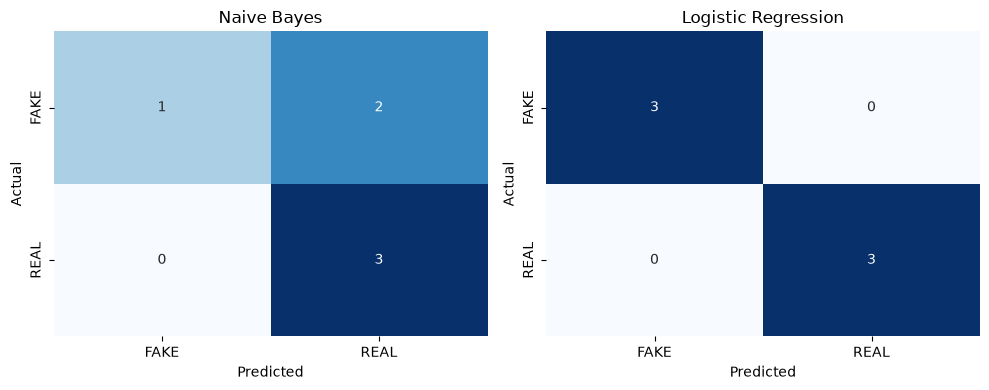

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, preds, title in zip(axes, [nb_preds, lr_preds], ["Naive Bayes", "Logistic Regression"]):
    cm = confusion_matrix(y_test, preds, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'], ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


**Reading a confusion matrix:** the diagonal (top-left to bottom-right) is what the model got
*right*. Off-diagonal cells are errors — top-right is "actually FAKE, predicted REAL" (the more
dangerous mistake in a real fake-news detector), bottom-left is "actually REAL, predicted FAKE".


## 8. Try it on brand-new sentences

The real test: feed the trained model sentences it has *never* seen, using the exact same
preprocessing + vectorizing pipeline.


In [18]:
def predict_news(text, model=lr_model):
    cleaned = preprocess(text)
    vec = tfidf_vectorizer_full.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    label = "REAL" if pred == 1 else "FAKE"
    confidence = prob[pred]
    return label, confidence

new_examples = [
    "The government announced a new tax policy effective from next fiscal year",
    "Secret underground city of lizard people discovered beneath the capital say insiders",
    "Local university launches a new scholarship program for engineering students",
    "Man claims he can predict earthquakes using his pet parrot experts baffled",
]

for text in new_examples:
    label, conf = predict_news(text)
    print(f"[{label:4s} | conf={conf:.2f}]  {text}")


[REAL | conf=0.55]  The government announced a new tax policy effective from next fiscal year
[FAKE | conf=0.50]  Secret underground city of lizard people discovered beneath the capital say insiders
[REAL | conf=0.54]  Local university launches a new scholarship program for engineering students
[FAKE | conf=0.53]  Man claims he can predict earthquakes using his pet parrot experts baffled


Notice the pipeline discipline here: **every** new sentence goes through the *same*
`preprocess()` → `tfidf_vectorizer_full.transform()` → `model.predict()` steps used during training.
This consistency (fit on train, only *transform* on new data — never re-fit) is one of the most
common places students introduce bugs, so it's worth calling out explicitly.


## 9. Recap: the full pipeline in one picture

```
Raw text
   │  lowercase, strip punctuation/numbers
   ▼
Cleaned text
   │  tokenize
   ▼
Tokens
   │  remove stopwords
   ▼
Meaningful tokens
   │  lemmatize
   ▼
Lemmatized tokens  ──►  join back into a string
   │  TfidfVectorizer.fit_transform()
   ▼
Numeric feature matrix (documents x vocabulary)
   │  train_test_split()
   ▼
Train Naive Bayes / Logistic Regression
   │
   ▼
Evaluate (accuracy, precision, recall, F1, confusion matrix)
   │
   ▼
Predict on new, unseen text
```

## 10. Exercises for students

1. **Expand the dataset** — add 10 more REAL and 10 more FAKE sentences of your own. Does accuracy
   change? Why might a bigger dataset behave differently?
2. **Swap the vectorizer** — retrain both models using `CountVectorizer` (BoW) instead of TF-IDF.
   Compare results. Which features (words) end up mattering most for each?
3. **Inspect Logistic Regression weights** — use `lr_model.coef_` alongside
   `tfidf_vectorizer_full.get_feature_names_out()` to find the top 5 words pushing toward FAKE and
   the top 5 pushing toward REAL. Do they match your intuition?
4. **Try n-grams** — set `TfidfVectorizer(ngram_range=(1,2))` to include two-word phrases
   (e.g. `"secret government"`). Does this help or hurt on such a small dataset? Why?
5. **Stress-test the model** — write 3 tricky sentences that mix real-sounding structure with
   fake-sounding content (or vice versa). Does the model get fooled? What does that tell you about
   the limits of word-frequency-based features?
